<a href="https://colab.research.google.com/github/dalilahbiamby/FashionMNIST_MNIST_Experiments/blob/main/Dense_Sparse_HPO_Experiments(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Cell 1: Set up and GPU verification

import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import sklearn
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report
import scipy
from scipy.optimize import curve_fit
import cv2, gc, json, warnings
warnings.filterwarnings('ignore')

# Software versions (for thesis reproducibility section)
print("=== SOFTWARE VERSIONS ===")
print("Python      :", sys.version.split()[0])
print("TensorFlow  :", tf.__version__)
print("Keras       :", keras.__version__)
print("NumPy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("SciPy       :", scipy.__version__)
print("OpenCV      :", cv2.__version__)
print("Matplotlib  :", matplotlib.__version__)

# Check GPU availability on Colab
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", gpus if gpus else "None — check Runtime > Change runtime type")

# Global seeds ensure reproducibility across all runs
tf.random.set_seed(42)
#np.random.seed(42)

=== SOFTWARE VERSIONS ===
Python      : 3.12.13
TensorFlow  : 2.20.0
Keras       : 3.13.2
NumPy       : 2.0.2
scikit-learn: 1.6.1
SciPy       : 1.16.3
OpenCV      : 4.13.0
Matplotlib  : 3.10.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#Cell 2: Experiment configuration

# Seven training subset sizes: 1% to 100% of 60,000 images
SAMPLE_SIZES       = [600, 3000, 6000, 15000, 30000, 45000, 60000]
SAMPLE_PERCENTAGES = ["1%", "5%", "10%", "25%", "50%", "75%", "100%"]

# Baseline configuration as specified by supervisor
# Note: kernel_size=2 means 2x2 convolutional filters throughout
BASELINE_CONFIG = {
    "name":        "baseline",
    "lr":          0.001,   # Adam learning rate
    "batch_size":  64,
    "dropout":     0.3,
    "optimizer":   "adam",
    "dense_units": 128,     # neurons in the hidden dense layer
    "kernel_size": 2,       # 2x2 kernels as specified
}

N_SEEDS          = 3        # seeds 0, 1, 2
EPOCHS           = 25
VALIDATION_SPLIT = 0.1      # 10% of each subset held for validation monitoring

# Fashion-MNIST class names for F1 and visualisation
FMNIST_CLASS_NAMES = [
    "T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

# Kernel pattern configurations: each defines which positions in the
# kernel are active (1) or zeroed out (0).
# Dense/edge/diagonal tested at 2x2, 3x3, and 4x4.
# Central is not defined for 2x2 — a 2x2 kernel has no single centre pixel.
KERNEL_CONFIGS = [
    # ---- Dense: all kernel positions active ----
    {"name": "dense_2x2",    "pattern": "dense",
     "kernel_size": 2, "mask": np.ones((2, 2), dtype=np.float32),
     "desc": "All positions (2×2)"},
    {"name": "dense_3x3",    "pattern": "dense",
     "kernel_size": 3, "mask": np.ones((3, 3), dtype=np.float32),
     "desc": "All positions (3×3)"},
    {"name": "dense_4x4",    "pattern": "dense",
     "kernel_size": 4, "mask": np.ones((4, 4), dtype=np.float32),
     "desc": "All positions (4×4)"},

    # ---- Edge: border ring only, interior zeroed ----
    {"name": "edge_2x2",     "pattern": "edge",
     "kernel_size": 2,
     "mask": np.array([[1, 1], [0, 0]], dtype=np.float32),
     "desc": "Top-row edge (2×2)"},
    {"name": "edge_3x3",     "pattern": "edge",
     "kernel_size": 3,
     "mask": np.array([[1,1,1],[1,0,1],[1,1,1]], dtype=np.float32),
     "desc": "Border ring (3×3)"},
    {"name": "edge_4x4",     "pattern": "edge",
     "kernel_size": 4,
     "mask": np.array([[1,1,1,1],[1,0,0,1],[1,0,0,1],[1,1,1,1]], dtype=np.float32),
     "desc": "Border ring (4×4)"},

    # ---- Diagonal: corner positions only ----
    {"name": "diagonal_2x2", "pattern": "diagonal",
     "kernel_size": 2,
     "mask": np.array([[1, 0], [0, 1]], dtype=np.float32),
     "desc": "Main diagonal (2×2)"},
    {"name": "diagonal_3x3", "pattern": "diagonal",
     "kernel_size": 3,
     "mask": np.array([[1,0,1],[0,0,0],[1,0,1]], dtype=np.float32),
     "desc": "Four corners (3×3)"},
    {"name": "diagonal_4x4", "pattern": "diagonal",
     "kernel_size": 4,
     "mask": np.array([[1,0,0,1],[0,0,0,0],[0,0,0,0],[1,0,0,1]], dtype=np.float32),
     "desc": "Four corners (4×4)"},

    # ---- Central: centre region only — N/A for 2×2 ----
    {"name": "central_3x3",  "pattern": "central",
     "kernel_size": 3,
     "mask": np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float32),
     "desc": "Centre pixel (3×3)"},
    {"name": "central_4x4",  "pattern": "central",
     "kernel_size": 4,
     "mask": np.array([[0,0,0,0],[0,1,1,0],[0,1,1,0],[0,0,0,0]], dtype=np.float32),
     "desc": "Inner 2×2 centre (4×4)"},
]

KERNEL_SIZE_OPTIONS = [2, 3, 4]
PATTERN_TYPES       = ["dense", "edge", "diagonal", "central"]
print(f"Kernel configurations: {len(KERNEL_CONFIGS)} total")
for kc in KERNEL_CONFIGS:
    active = int(kc["mask"].sum())
    print(f"  {kc['name']:<14}  {active:>2} active positions  — {kc['desc']}")

# Canny edge detection thresholds — calibrated for 28x28 grayscale images
CANNY_LOW, CANNY_HIGH = 50, 150

# Coordinate array lengths for sparse pipeline.
# Set just above the 99th percentile of active-pixel counts
# so fewer than ~1% of images are truncated.
MAX_ACTIVE_FM = 260   # Fashion-MNIST: clothing outlines are denser
MAX_ACTIVE_MN = 120   # MNIST: digit outlines are sparser

print("Configuration ready.")
print(f"  Kernel sizes tested: {KERNEL_SIZE_OPTIONS}")
print(f"  Pattern types: {PATTERN_TYPES}")
print(f"  Hyperparameter configs: defined in Cell 10")

Kernel configurations: 11 total
  dense_2x2        4 active positions  — All positions (2×2)
  dense_3x3        9 active positions  — All positions (3×3)
  dense_4x4       16 active positions  — All positions (4×4)
  edge_2x2         2 active positions  — Top-row edge (2×2)
  edge_3x3         8 active positions  — Border ring (3×3)
  edge_4x4        12 active positions  — Border ring (4×4)
  diagonal_2x2     2 active positions  — Main diagonal (2×2)
  diagonal_3x3     4 active positions  — Four corners (3×3)
  diagonal_4x4     4 active positions  — Four corners (4×4)
  central_3x3      1 active positions  — Centre pixel (3×3)
  central_4x4      4 active positions  — Inner 2×2 centre (4×4)
Configuration ready.
  Kernel sizes tested: [2, 3, 4]
  Pattern types: ['dense', 'edge', 'diagonal', 'central']
  Hyperparameter configs: defined in Cell 10


In [4]:
#Cell 3: The data loading and preprocessing functions

def load_and_preprocess(dataset_name):
    """
    Load Fashion-MNIST or MNIST, normalise pixels to [0,1],
    and append a channel dimension → shape (N, 28, 28, 1).
    Normalisation stabilises gradient flow during training (Solá & Sevilla, 1997).
    """
    if dataset_name == "fashion_mnist":
        (X_tr, y_tr), (X_te, y_te) = keras.datasets.fashion_mnist.load_data()
    else:
        (X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
    X_tr = (X_tr.astype("float32") / 255.0)[..., np.newaxis]
    X_te = (X_te.astype("float32") / 255.0)[..., np.newaxis]
    print(f"  {dataset_name.upper()}: train {X_tr.shape}, test {X_te.shape}")
    return X_tr, y_tr, X_te, y_te


def make_edge_outlines(images, threshold=25, min_contour_area=10):
    """
    Produces clean external-only binary outlines.

    Improvements over basic contour extraction:
      1. Otsu's thresholding: automatically finds the optimal threshold
         per image rather than using a fixed global value, adapting to
         each image's brightness distribution. Better than a fixed
         threshold=25 for images with varying background levels.
      2. Morphological closing (MORPH_CLOSE): fills tiny gaps in the
         binary foreground mask before contour extraction, producing
         a more continuous outline rather than a fragmented one.
      3. Minimum contour area filter: drops tiny noise blobs (dust pixels,
         compression artifacts) that produce spurious micro-outlines.
         min_contour_area=10 pixels removes isolated dots while keeping
         all meaningful garment/digit structure on a 28x28 image.
      4. Largest contour priority: draws the largest contour first so
         the primary object silhouette is always captured even if small
         noise contours survive the area filter.
    """
    uint8    = (images.squeeze(-1) * 255).astype(np.uint8)
    outlines = np.zeros_like(uint8, dtype=np.float32)

    # Morphological kernel for gap closing
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))

    for i in range(len(uint8)):
        img = uint8[i]

        # Otsu's method: finds optimal threshold automatically per image
        # by maximising between-class variance in the pixel histogram.
        # THRESH_BINARY_INV inverts so the foreground object becomes white.
        # For Fashion-MNIST/MNIST (dark background, bright object), standard
        # THRESH_BINARY is correct; INV would be needed if background is bright.
        _, binary = cv2.threshold(
            img, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Morphological closing: dilate then erode.
        # Fills small gaps and holes in the foreground mask so the contour
        # extractor sees a more solid silhouette rather than a patchy one.
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        # Extract only outermost contours
        contours, _ = cv2.findContours(
            binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        # Filter out tiny noise blobs below minimum area
        contours = [c for c in contours if cv2.contourArea(c) >= min_contour_area]

        # Draw contours on black canvas, largest first
        canvas = np.zeros_like(img)
        if contours:
            contours = sorted(contours, key=cv2.contourArea, reverse=True)
            cv2.drawContours(canvas, contours, -1, 255, 1)

        outlines[i] = (canvas > 0).astype(np.float32)

    return outlines[..., np.newaxis]

def stratified_sample(images, labels, n_samples, seed):
    """
    Draw a class-proportional subset using StratifiedShuffleSplit.
    Preserving class balance is critical at small sizes (600, 3000 images)
    where an unconstrained draw could under-represent rare classes.
    """
    if n_samples >= len(images):
        return images, labels
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=seed)
    idx, _ = next(sss.split(images, labels))
    return images[idx], labels[idx]


def extract_coords(outlines, max_active):
    """
    Extract (row, col) of every non-zero pixel per image into a fixed-length
    array padded with sentinel -1. Images with more active pixels than
    max_active are truncated in row-major order (top-to-bottom scan).
    """
    N      = len(outlines)
    coords = np.full((N, max_active, 2), -1, dtype=np.int32)
    n_trunc = 0
    for i in range(N):
        rows, cols = np.nonzero(outlines[i, :, :, 0])
        n = len(rows)
        if n > max_active:
            n_trunc += 1
            rows, cols, n = rows[:max_active], cols[:max_active], max_active
        coords[i, :n, 0] = rows
        coords[i, :n, 1] = cols
    if n_trunc:
        pct = 100 * n_trunc / N
        print(f"  Truncated {n_trunc}/{N} images ({pct:.1f}%)")
    return coords


def _get_optimizer(config):
    if config["optimizer"] == "adam":
        return keras.optimizers.Adam(learning_rate=config["lr"])
    return keras.optimizers.SGD(learning_rate=config["lr"], momentum=0.9)

In [5]:
#Cell 5: Model architectures

# ---- 5a. MaskedConv2D — kernel pattern experiments ----

class MaskedConv2D(layers.Layer):
    """
    Standard Conv2D where a fixed binary mask permanently zeroes
    selected kernel positions on every forward pass.

    Motivation: tests whether specific spatial relationships
    (border, diagonal, centre) drive CNN performance, or whether
    the full kernel is needed. The mask is non-trainable; weights
    at active positions are fully trainable.

    Patterns tested:
      dense:    2x2, all 4 positions — baseline
      edge:     3x3, 8 border positions, centre zeroed
      diagonal: 3x3, 4 corner positions only
      central:  3x3, centre only (equivalent to 1x1 convolution)
    """
    def __init__(self, filters, mask_2d, activation=None, padding="same", **kwargs):
        super().__init__(**kwargs)
        self.filters    = filters
        self.mask_2d    = np.array(mask_2d, dtype=np.float32)
        self.activation = keras.activations.get(activation)
        self.padding    = padding

    def build(self, input_shape):
        in_ch = input_shape[-1]
        k     = self.mask_2d.shape[0]
        self.kernel = self.add_weight(
            shape=(k, k, in_ch, self.filters),
            initializer="glorot_uniform", trainable=True, name="kernel")
        self.bias = self.add_weight(
            shape=(self.filters,), initializer="zeros", trainable=True, name="bias")
        # Expand mask to broadcast over in_channels and filters
        self.mask_t = tf.constant(
            self.mask_2d[:, :, np.newaxis, np.newaxis], dtype=tf.float32)

    def call(self, inputs):
        effective = self.kernel * self.mask_t           # zeroes masked positions
        x = tf.nn.conv2d(inputs, effective,
                          strides=[1,1,1,1], padding=self.padding.upper())
        x = tf.nn.bias_add(x, self.bias)
        return self.activation(x) if self.activation else x


# ---- 5b. Dense CNN builders ----

def build_dense_cnn(config=BASELINE_CONFIG, num_classes=10):
    """
    Standard two-block shallow CNN with the supervisor-specified baseline.
    Kernel size taken from config so it works for all OFAT variants.
    """
    k = config["kernel_size"]
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (k, k), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (k, k), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(config["dense_units"], activation="relu"),
        layers.Dropout(config["dropout"]),
        layers.Dense(num_classes, activation="softmax"),
    ], name=f"dense_{config['name']}")
    model.compile(optimizer=_get_optimizer(config),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


def build_masked_dense_cnn(kc, base_config=BASELINE_CONFIG, num_classes=10):
    """kc is one entry from KERNEL_CONFIGS."""
    mask = kc["mask"]
    cfg  = {**base_config, "kernel_size": kc["kernel_size"]}
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        MaskedConv2D(32, mask, activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        MaskedConv2D(64, mask, activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(cfg["dense_units"], activation="relu"),
        layers.Dropout(cfg["dropout"]),
        layers.Dense(num_classes, activation="softmax"),
    ], name=f"masked_{kc['name']}")
    model.compile(optimizer=_get_optimizer(cfg),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


# ---- 5c. SparseConv2D layer ----

class SparseConv2D(layers.Layer):
    """
    Convolution restricted to active (non-zero edge) pixel coordinates.
    Follows the submanifold sparse convolution principle: computation only
    occurs at active spatial locations, not across the full 28x28 grid.

    Per active coordinate:
      1. Gather k×k pixel neighbourhood from zero-padded input
      2. (Optional) apply binary kernel mask for pattern experiments
      3. Matrix-multiply gathered patches with shared weight matrix
      4. Scatter result back to the full spatial feature map

    Sentinel coordinates (-1) are excluded via a validity mask.
    """
    def __init__(self, filters, kernel_size, activation=None,
                 kernel_mask=None, **kwargs):
        super().__init__(**kwargs)
        self.filters        = filters
        self.kernel_size    = kernel_size
        self.activation     = keras.activations.get(activation)
        self.kernel_mask_np = kernel_mask  # optional numpy (k,k) binary mask

    def build(self, input_shape):
        images_shape, _ = input_shape
        in_ch = images_shape[-1]
        k     = self.kernel_size
        self.kernel = self.add_weight(
            shape=(k * k * in_ch, self.filters),
            initializer="glorot_uniform", trainable=True, name="kernel")
        self.bias = self.add_weight(
            shape=(self.filters,), initializer="zeros", trainable=True, name="bias")
        # Flat mask vector matching patch_tensor's last dimension (k*k*in_ch)
        if self.kernel_mask_np is not None:
            flat = self.kernel_mask_np.flatten()           # (k*k,)
            flat = np.repeat(flat, in_ch).astype(np.float32)  # (k*k*in_ch,)
            self.mask_vec = tf.constant(flat, dtype=tf.float32)
        else:
            self.mask_vec = None

    def call(self, inputs):
        images, coords = inputs
        k   = self.kernel_size
        pad = k // 2
        H   = images.shape[1]
        W   = images.shape[2]
        padded = tf.pad(images, [[0,0],[pad,pad],[pad,pad],[0,0]])

        def process_one(args):
            img_p, coord = args
            valid = tf.reduce_all(coord >= 0, axis=-1)       # exclude -1 sentinels
            safe  = tf.maximum(coord, 0)
            rows  = safe[:, 0] + pad
            cols  = safe[:, 1] + pad
            # Gather k×k neighbourhood for every active coordinate
            patches = []
            # range(k) with -pad offset gives exactly k positions
            # for any kernel size (2, 3, or 4), fixing a bug with even kernels
            for dr in range(k):
                for dc in range(k):
                    idx = tf.stack([rows - pad + dr, cols - pad + dc], axis=-1)
                    patches.append(tf.gather_nd(img_p, idx))
            patch_tensor = tf.concat(patches, axis=-1)        # (M, k*k*in_ch)
            # Apply kernel mask if pattern experiment is active
            if self.mask_vec is not None:
                patch_tensor = patch_tensor * self.mask_vec
            out = tf.matmul(patch_tensor, self.kernel) + self.bias  # (M, filters)
            out = out * tf.cast(valid, tf.float32)[:, None]          # zero sentinels
            return tf.tensor_scatter_nd_add(
                tf.zeros((H, W, self.filters), dtype=tf.float32),
                tf.cast(safe, tf.int32), out)

        outputs = tf.map_fn(process_one, (padded, coords),
                            fn_output_signature=tf.float32)
        outputs.set_shape((None, H, W, self.filters))  # fix static shape for Keras
        return self.activation(outputs) if self.activation else outputs


def build_sparse_cnn(config=BASELINE_CONFIG, max_active=MAX_ACTIVE_FM,
                     num_classes=10, kernel_mask=None):
    """
    Sparse two-block CNN: two SparseConv2D layers sharing the same
    active-coordinate input, followed by standard pooling, dense, and output.
    Structure mirrors the dense baseline exactly for direct comparison.
    """
    k        = config["kernel_size"]
    img_in   = layers.Input(shape=(28, 28, 1),       name="image")
    coord_in = layers.Input(shape=(max_active, 2),
                             dtype="int32",            name="coords")

    x   = SparseConv2D(32, k, activation="relu",
                        kernel_mask=kernel_mask)([img_in, coord_in])
    x   = SparseConv2D(64, k, activation="relu",
                        kernel_mask=kernel_mask)([x, coord_in])
    x   = layers.MaxPooling2D((2, 2))(x)
    x   = layers.MaxPooling2D((2, 2))(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(config["dense_units"], activation="relu")(x)
    x   = layers.Dropout(config["dropout"])(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=[img_in, coord_in], outputs=out,
                        name=f"sparse_{config['name']}")
    model.compile(optimizer=_get_optimizer(config),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


# Print architecture summaries
print("=== Dense CNN (baseline) ===")
build_dense_cnn().summary()

=== Dense CNN (baseline) ===


Model: "dense_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,242 (1.57 MB)

 Trainable params: 411,242 (1.57 MB)

 Non-trainable params: 0 (0.00 B)


=== HPO: FASHION_MNIST — DENSE ===
  FASHION_MNIST: train (60000, 28, 28, 1), test (10000, 28, 28, 1)
  Resuming from checkpoint: /content/drive/MyDrive/thesis_checkpoints/hpo_fashion_mnist_dense.json
  1% already complete — skipping
  5% already complete — skipping
  10% already complete — skipping
  25% already complete — skipping
  50% already complete — skipping
  75% already complete — skipping
  100% already complete — skipping

=== HPO: MNIST — DENSE ===
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  MNIST: train (60000, 28, 28, 1), test (10000, 28, 28, 1)
  Resuming from checkpoint: /content/drive/MyDrive/thesis_checkpoints/hpo_mnist_dense.json
  1% already complete — skipping
  5% already complete — skipping
  10% already complete — skipping
  25% already complete — skipping
  50% already complete — skipping
  75% already complete — skipping
  100% already complete — skipping

=== HPO: FASHION_MNIST — SPARSE ===
  FASHION_MNIST: train (60000, 28, 28, 1), test (10000, 28

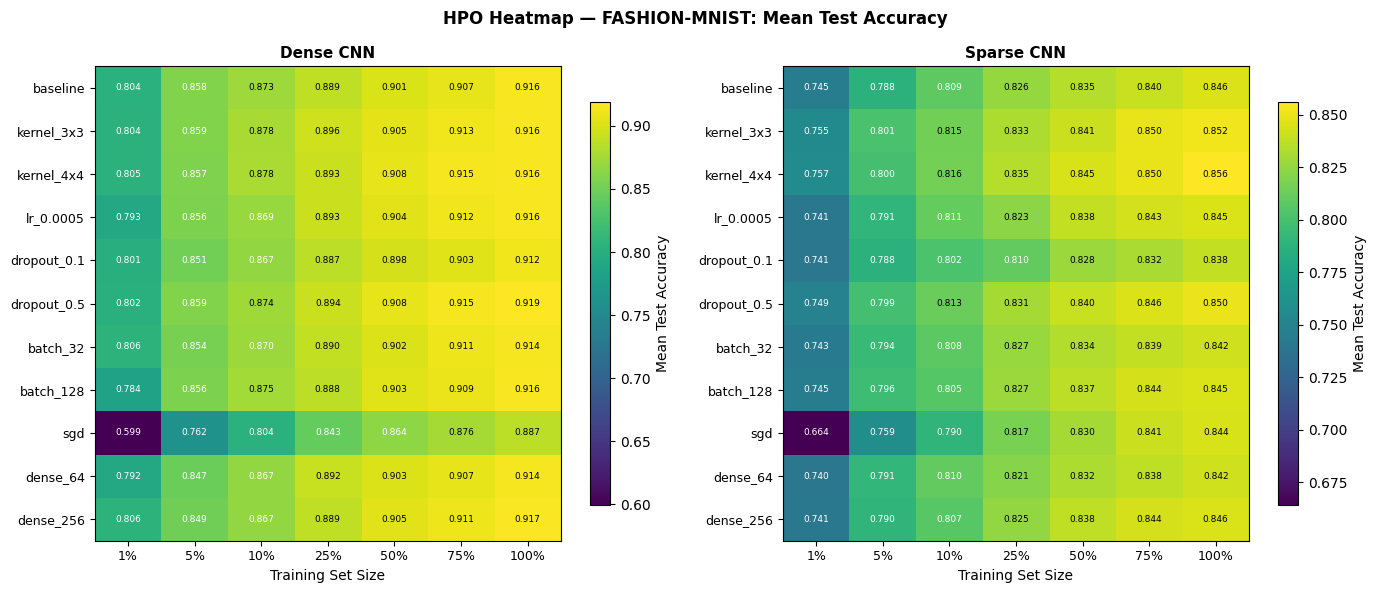

Saved: hpo_heatmap_fashion_mnist.png


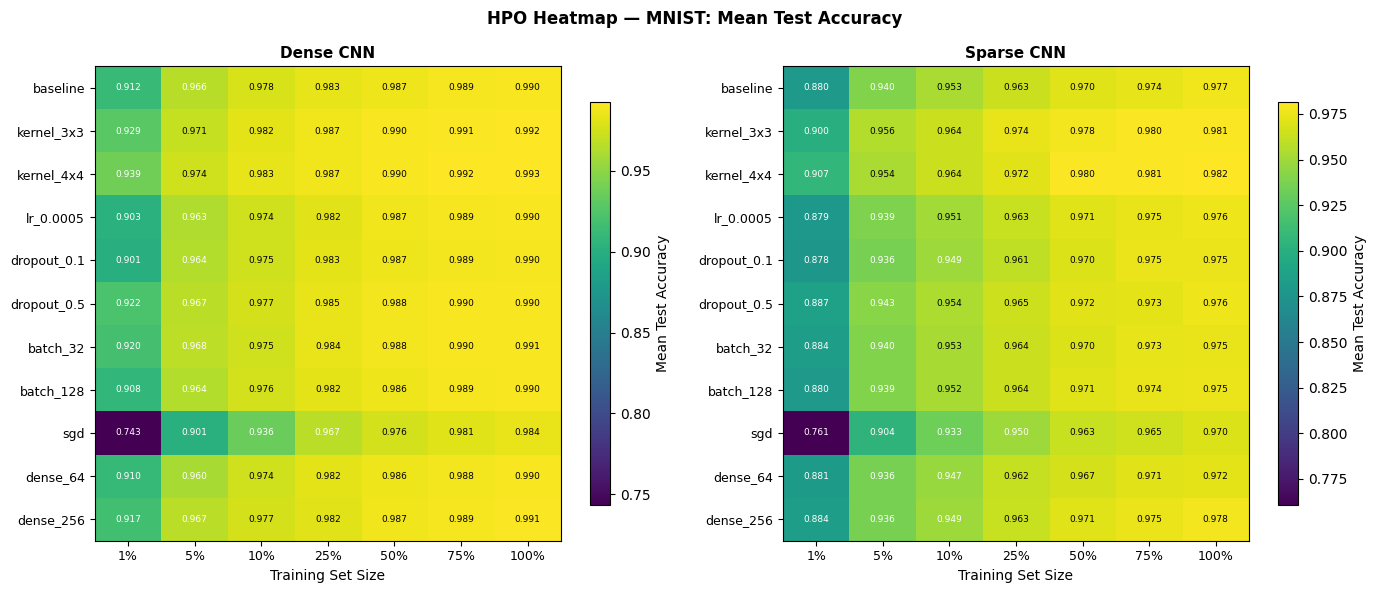

Saved: hpo_heatmap_mnist.png

✓ ALL EXPERIMENTS COMPLETE


In [11]:
# Cell 10: OFAT Hyperparameter tuning  (final: per-seed checkpointing + resume)

import os

TUNING_CONFIGS = [
    {"name":"baseline",    "lr":0.001,  "batch_size":64,  "dropout":0.3, "optimizer":"adam","dense_units":128,"kernel_size":2},
    {"name":"kernel_3x3",  "lr":0.001,  "batch_size":64,  "dropout":0.3, "optimizer":"adam","dense_units":128,"kernel_size":3},
    {"name":"kernel_4x4",  "lr":0.001,  "batch_size":64,  "dropout":0.3, "optimizer":"adam","dense_units":128,"kernel_size":4},
    {"name":"lr_0.0005",   "lr":0.0005, "batch_size":64,  "dropout":0.3, "optimizer":"adam","dense_units":128,"kernel_size":2},
    {"name":"dropout_0.1", "lr":0.001,  "batch_size":64,  "dropout":0.1, "optimizer":"adam","dense_units":128,"kernel_size":2},
    {"name":"dropout_0.5", "lr":0.001,  "batch_size":64,  "dropout":0.5, "optimizer":"adam","dense_units":128,"kernel_size":2},
    {"name":"batch_32",    "lr":0.001,  "batch_size":32,  "dropout":0.3, "optimizer":"adam","dense_units":128,"kernel_size":2},
    {"name":"batch_128",   "lr":0.001,  "batch_size":128, "dropout":0.3, "optimizer":"adam","dense_units":128,"kernel_size":2},
    {"name":"sgd",         "lr":0.001,  "batch_size":64,  "dropout":0.3, "optimizer":"sgd", "dense_units":128,"kernel_size":2},
    {"name":"dense_64",    "lr":0.001,  "batch_size":64,  "dropout":0.3, "optimizer":"adam","dense_units":64, "kernel_size":2},
    {"name":"dense_256",   "lr":0.001,  "batch_size":64,  "dropout":0.3, "optimizer":"adam","dense_units":256,"kernel_size":2},
]

# Checkpoints live on Drive so a runtime disconnect cannot destroy them.
# Requires: from google.colab import drive; drive.mount('/content/drive')
CKPT_DIR = "/content/drive/MyDrive/thesis_checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)


def run_hpo(dataset_name, model_type, max_active, configs=TUNING_CONFIGS):
    """
    Train all configs at all 7 sizes x 3 seeds.
    Checkpoints to Drive after EVERY seed; resumes at seed level.
    """
    print(f"\n=== HPO: {dataset_name.upper()} — {model_type.upper()} ===")
    X_tr, y_tr, X_te, y_te = load_and_preprocess(dataset_name)

    if model_type == "sparse":
        E_te = make_edge_outlines(X_te)
        C_te = extract_coords(E_te, max_active)

    ckpt_path = f"{CKPT_DIR}/hpo_{dataset_name}_{model_type}.json"

    # ---- RESUME: load existing checkpoint if present ----
    if os.path.exists(ckpt_path):
        with open(ckpt_path) as f:
            by_size = json.load(f)
        print(f"  Resuming from checkpoint: {ckpt_path}")
    else:
        by_size = {sl: {c["name"]: [] for c in configs}
                   for sl in SAMPLE_PERCENTAGES}

    for sl, n in zip(SAMPLE_PERCENTAGES, SAMPLE_SIZES):
        # Seed-level resume: a seed counts as done only if ALL configs have it.
        done_seeds = min(len(by_size[sl][c["name"]]) for c in configs)
        # Discard any partial (mid-seed crash) results beyond the last full seed
        for c in configs:
            by_size[sl][c["name"]] = by_size[sl][c["name"]][:done_seeds]

        if done_seeds == N_SEEDS:
            print(f"  {sl} already complete — skipping")
            continue

        print(f"\n  {sl} ({n})" +
              (f" — resuming at seed {done_seeds}" if done_seeds else ""))

        for seed in range(done_seeds, N_SEEDS):
            tf.random.set_seed(seed); np.random.seed(seed)
            X_sub, y_sub = stratified_sample(X_tr, y_tr, n, seed)
            if model_type == "sparse":
                E_sub = make_edge_outlines(X_sub)
                C_sub = extract_coords(E_sub, max_active)

            for cfg in configs:
                if model_type == "dense":
                    model = build_dense_cnn(cfg)
                    model.fit(X_sub, y_sub, epochs=EPOCHS,
                              batch_size=cfg["batch_size"],
                              validation_split=VALIDATION_SPLIT, verbose=0)
                    _, acc = model.evaluate(X_te, y_te, verbose=0)
                else:
                    model = build_sparse_cnn(cfg, max_active)
                    model.fit([E_sub, C_sub], y_sub, epochs=EPOCHS,
                              batch_size=cfg["batch_size"],
                              validation_split=VALIDATION_SPLIT, verbose=0)
                    _, acc = model.evaluate([E_te, C_te], y_te, verbose=0)
                by_size[sl][cfg["name"]].append(float(acc))
                del model; keras.backend.clear_session(); gc.collect()

            # ---- Checkpoint after EVERY seed ----
            with open(ckpt_path, "w") as f:
                json.dump(by_size, f)

            # Per-seed results (survive in notebook output as second safety net)
            print(f"    Seed {seed}: " + ", ".join(
                f"{cfg['name']}={by_size[sl][cfg['name']][-1]:.4f}"
                for cfg in configs))
            print(f"    ✓ Checkpoint after seed {seed}")

        # Per-size summary: mean ± std across seeds
        print(f"  ✓ Size {sl} complete")
        for cfg in configs:
            vals = by_size[sl][cfg["name"]]
            print(f"    {cfg['name']:<14} {np.mean(vals):.4f} ± {np.std(vals):.4f}")

    # Build tidy summary list
    summary = [{"size": sl, "config": cfg["name"],
                "mean": float(np.mean(by_size[sl][cfg["name"]])),
                "std":  float(np.std( by_size[sl][cfg["name"]]))}
               for sl in SAMPLE_PERCENTAGES for cfg in configs]
    return {"dataset": dataset_name, "model": model_type, "results": summary}


# Dense runs first (fast) so half the results exist early; sparse after.
hpo = {}
for ds in ["fashion_mnist","mnist"]:
    ma = MAX_ACTIVE_FM if ds=="fashion_mnist" else MAX_ACTIVE_MN
    hpo[(ds,"dense")] = run_hpo(ds, "dense", ma)
for ds in ["fashion_mnist","mnist"]:
    ma = MAX_ACTIVE_FM if ds=="fashion_mnist" else MAX_ACTIVE_MN
    hpo[(ds,"sparse")] = run_hpo(ds, "sparse", ma)


# ---- HPO table at 100% ----
for ds in ["fashion_mnist","mnist"]:
    for mt in ["dense","sparse"]:
        rows = [r for r in hpo[(ds,mt)]["results"] if r["size"]=="100%"]
        base = next(r["mean"] for r in rows if r["config"]=="baseline")
        print(f"\nHPO @ 100% — {ds.replace('_','-').upper()} {mt.upper()}")
        print(f"{'Config':<14} {'Mean':>8} {'Std':>7} {'Δ baseline':>12}")
        print("-"*44)
        for r in rows:
            print(f"{r['config']:<14} {r['mean']:>8.4f} {r['std']:>7.4f}"
                  f" {r['mean']-base:>+12.4f}")


# ---- HPO heatmap (one per dataset) ----
def plot_hpo_heatmap(dataset_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    cfg_names = [c["name"] for c in TUNING_CONFIGS]

    for ax, mt in zip(axes, ["dense","sparse"]):
        grid = np.zeros((len(TUNING_CONFIGS), len(SAMPLE_PERCENTAGES)))
        for r in hpo[(dataset_name,mt)]["results"]:
            i = cfg_names.index(r["config"])
            j = SAMPLE_PERCENTAGES.index(r["size"])
            grid[i, j] = r["mean"]

        im = ax.imshow(grid, cmap="viridis", aspect="auto",
                        vmin=grid.min(), vmax=grid.max())
        ax.set_xticks(range(len(SAMPLE_PERCENTAGES)))
        ax.set_xticklabels(SAMPLE_PERCENTAGES, fontsize=9)
        ax.set_yticks(range(len(cfg_names)))
        ax.set_yticklabels(cfg_names, fontsize=9)
        ax.set_xlabel("Training Set Size")
        ax.set_title(f"{mt.capitalize()} CNN", fontsize=11, fontweight="bold")
        plt.colorbar(im, ax=ax, label="Mean Test Accuracy", shrink=0.85)
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                ax.text(j, i, f"{grid[i,j]:.3f}", ha="center", va="center",
                        fontsize=6.5,
                        color="white" if grid[i,j] < grid.mean() else "black")

    ds_label = dataset_name.replace("_","-").upper()
    plt.suptitle(f"HPO Heatmap — {ds_label}: Mean Test Accuracy",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    fname = f"hpo_heatmap_{dataset_name}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show(); print(f"Saved: {fname}")

plot_hpo_heatmap("fashion_mnist")
plot_hpo_heatmap("mnist")

print("\n✓ ALL EXPERIMENTS COMPLETE")